In [1]:
pip install pandas numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [3]:
np.random.seed(42)

In [4]:
customers = pd.DataFrame({
    "customer_id": [f"C{i}" for i in range(100)],
    "age": np.random.randint(21, 60, 100),
    "occupation": np.random.choice(["Engineer", "Doctor", "Student", "Business"], 100),
    "annual_income": np.random.randint(200000, 1500000, 100),
    "city": np.random.choice(["Chennai", "Bangalore", "Mumbai"], 100)
})

In [5]:
accounts = pd.DataFrame({
    "account_id": [f"A{i}" for i in range(100)],
    "customer_id": customers["customer_id"],
    "account_type": np.random.choice(["Savings", "Current"], 100),
    "balance": np.random.randint(1000, 500000, 100),
    "account_open_date": [datetime.now() - timedelta(days=np.random.randint(1, 1000)) for _ in range(100)]
})

In [6]:
transactions = pd.DataFrame({
    "transaction_id": [f"T{i}" for i in range(1000)],
    "account_id": np.random.choice(accounts["account_id"], 1000),
    "transaction_amount": np.random.randint(100, 50000, 1000),
    "merchant_category": np.random.choice(["Food", "Travel", "Shopping", "Bills"], 1000),
    "transaction_type": np.random.choice(["Debit", "Credit"], 1000),
    "location": np.random.choice(["Chennai", "Bangalore", "Mumbai"], 1000),
    "timestamp": [datetime.now() - timedelta(days=np.random.randint(1, 365)) for _ in range(1000)]
})

In [7]:
fraud = pd.DataFrame({
    "transaction_id": transactions["transaction_id"],
    "fraud_flag": np.random.choice([0, 1], 1000, p=[0.9, 0.1])  # 10% fraud
})

In [8]:
customers.to_csv("customers.csv", index=False)
accounts.to_csv("accounts.csv", index=False)
transactions.to_csv("transactions.csv", index=False)
fraud.to_csv("fraud_labels.csv", index=False)

print("Datasets created successfully")

Datasets created successfully


------

In [68]:
df = transactions.merge(accounts, on="account_id") \
                 .merge(customers, on="customer_id") \
                 .merge(fraud, on="transaction_id")

In [69]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [70]:
# Time feature
df["hour"] = df["timestamp"].dt.hour

# Night transaction
df["is_night"] = df["hour"].apply(lambda x: 1 if x < 6 or x > 22 else 0)

# Location mismatch
df["location_mismatch"] = (df["city"] != df["location"]).astype(int)

In [71]:
features = ["transaction_amount", "is_night", "location_mismatch"]

X = df[features]
y = df["fraud_flag"]

In [11]:
print(df.head())

  transaction_id account_id  transaction_amount merchant_category  \
0             T0        A26               23995              Food   
1             T1        A65                9255          Shopping   
2             T2         A4               31983          Shopping   
3             T3        A28               43294          Shopping   
4             T4        A36               43101             Bills   

  transaction_type   location                  timestamp customer_id  \
0            Debit  Bangalore 2026-02-24 12:04:56.317794         C26   
1            Debit     Mumbai 2025-10-16 12:04:56.317818         C65   
2            Debit     Mumbai 2025-09-01 12:04:56.317825          C4   
3           Credit  Bangalore 2025-08-09 12:04:56.317830         C28   
4            Debit    Chennai 2026-01-07 12:04:56.317834         C36   

  account_type  balance          account_open_date  age occupation  \
0      Savings   434374 2024-02-13 12:04:56.030154   48   Engineer   
1      Curre

In [12]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      1000 non-null   str           
 1   account_id          1000 non-null   str           
 2   transaction_amount  1000 non-null   int32         
 3   merchant_category   1000 non-null   str           
 4   transaction_type    1000 non-null   str           
 5   location            1000 non-null   str           
 6   timestamp           1000 non-null   datetime64[us]
 7   customer_id         1000 non-null   str           
 8   account_type        1000 non-null   str           
 9   balance             1000 non-null   int32         
 10  account_open_date   1000 non-null   datetime64[us]
 11  age                 1000 non-null   int32         
 12  occupation          1000 non-null   str           
 13  annual_income       1000 non-null   int32         
 14  city

In [13]:

print(df.describe())

       transaction_amount                   timestamp        balance  \
count         1000.000000                        1000    1000.000000   
mean         25916.442000  2025-10-15 21:29:25.119289  226528.521000   
min            205.000000  2025-04-22 12:04:56.318259    4267.000000   
25%          13163.250000  2025-07-19 12:04:56.318273   94008.000000   
50%          26624.500000  2025-10-13 12:04:56.319266  208869.000000   
75%          37879.500000  2026-01-10 12:04:56.320267  355802.000000   
max          49959.000000  2026-04-20 12:04:56.318975  496972.000000   
std          14287.309789                         NaN  146897.503218   

                account_open_date          age  annual_income   fraud_flag  \
count                        1000  1000.000000   1.000000e+03  1000.000000   
mean   2024-12-12 19:28:27.230289    39.378000   7.833573e+05     0.094000   
min    2023-07-27 12:04:56.030118    21.000000   2.028690e+05     0.000000   
25%    2024-04-15 12:04:56.030130    29

In [14]:
df["account_id"].isnull()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Name: account_id, Length: 1000, dtype: bool

In [15]:
df["customer_id"].isnull()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Name: customer_id, Length: 1000, dtype: bool

In [16]:
df["transaction_id"].isnull()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Name: transaction_id, Length: 1000, dtype: bool

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [73]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [74]:
y_pred = model.predict(X_test)

In [75]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.925


day 2

In [76]:
df["txn_count"] = df.groupby("customer_id")["transaction_id"].transform("count")

df["avg_amount"] = df.groupby("customer_id")["transaction_amount"].transform("mean")

df["amount_deviation"] = df["transaction_amount"] - df["avg_amount"]

In [77]:
features = [
    "transaction_amount",
    "amount_deviation",
    "txn_count",
    "is_night",
    "location_mismatch"
]

X = df[features]
y = df["fraud_flag"]

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [79]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [80]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [81]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94       185
           1       0.00      0.00      0.00        15

    accuracy                           0.90       200
   macro avg       0.46      0.48      0.47       200
weighted avg       0.85      0.90      0.87       200

ROC-AUC: 0.5581981981981982


In [82]:
import pandas as pd

feat_imp = pd.Series(model.feature_importances_, index=X.columns)
print(feat_imp.sort_values(ascending=False))

transaction_amount    0.388183
amount_deviation      0.371210
txn_count             0.202372
location_mismatch     0.038236
is_night              0.000000
dtype: float64


In [83]:
risk = df.groupby("customer_id")["fraud_flag"].sum()

def risk_level(x):
    if x > 5:
        return "High"
    elif x > 2:
        return "Medium"
    else:
        return "Low"

risk_score = risk.apply(risk_level)

print(risk_score.head())

customer_id
C0     Low
C1     Low
C10    Low
C11    Low
C12    Low
Name: fraud_flag, dtype: str


In [84]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.895
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       185
           1       0.00      0.00      0.00        15

    accuracy                           0.90       200
   macro avg       0.46      0.48      0.47       200
weighted avg       0.85      0.90      0.87       200



In [85]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.5581981981981982


In [17]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Axes: xlabel='fraud_flag'>

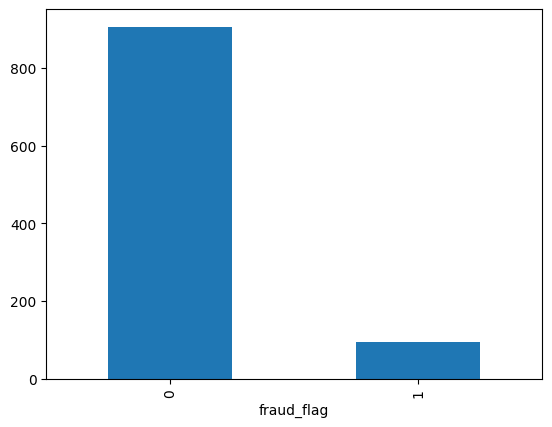

In [18]:
df["fraud_flag"].value_counts().plot(kind="bar")

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [20]:
features = ["transaction_amount", "hour", "is_night", "high_amount", "location_mismatch"]

X = df[features]
y = df["fraud_flag"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [36]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [37]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

importance = model.feature_importances_

for i, col in enumerate(features):
    print(col, ":", importance[i])

transaction_amount : 0.9847793453398842
hour : 0.0
is_night : 0.0
high_amount : 0.004176014175846175
location_mismatch : 0.011044640484269737


In [38]:
y_pred = model.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.79
              precision    recall  f1-score   support

           0       0.91      0.86      0.88       182
           1       0.07      0.11      0.09        18

    accuracy                           0.79       200
   macro avg       0.49      0.48      0.48       200
weighted avg       0.83      0.79      0.81       200



In [40]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [41]:
model = RandomForestClassifier(n_estimators=100, max_depth=5)

In [42]:
model.fit(X_train, y_train)
importances = model.feature_importances_

for i, col in enumerate(features):
    print(col, importances[i])

transaction_amount 0.943026713916846
hour 0.0
is_night 0.0
high_amount 0.012926137318648535
location_mismatch 0.04404714876450542


In [43]:
risk = df.groupby("customer_id")["fraud_flag"].sum()

def risk_level(x):
    if x > 5:
        return "High"
    elif x > 2:
        return "Medium"
    else:
        return "Low"

risk_score = risk.apply(risk_level)
print(risk_score)

customer_id
C0     Low
C1     Low
C10    Low
C11    Low
C12    Low
      ... 
C95    Low
C96    Low
C97    Low
C98    Low
C99    Low
Name: fraud_flag, Length: 100, dtype: str


In [44]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.86      0.88       182
           1       0.07      0.11      0.09        18

    accuracy                           0.79       200
   macro avg       0.49      0.48      0.48       200
weighted avg       0.83      0.79      0.81       200



In [45]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.561965811965812
